# Mintalib Expressions

Using [mintalib](https://pypi.org/project/mintalib/) polars expressions with `mplchart` on the polars backend.
`mintalib.expressions` returns `pl.Expr` factories that plug directly into `Chart.plot` — no pandas conversion needed.

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, LinePlot, AutoPlot
from mintalib.expressions import SMA, RSI, MACD, BBANDS, DMI

prices = sample_prices(backend="polars")

## SMA

Simple Moving Average overlay.

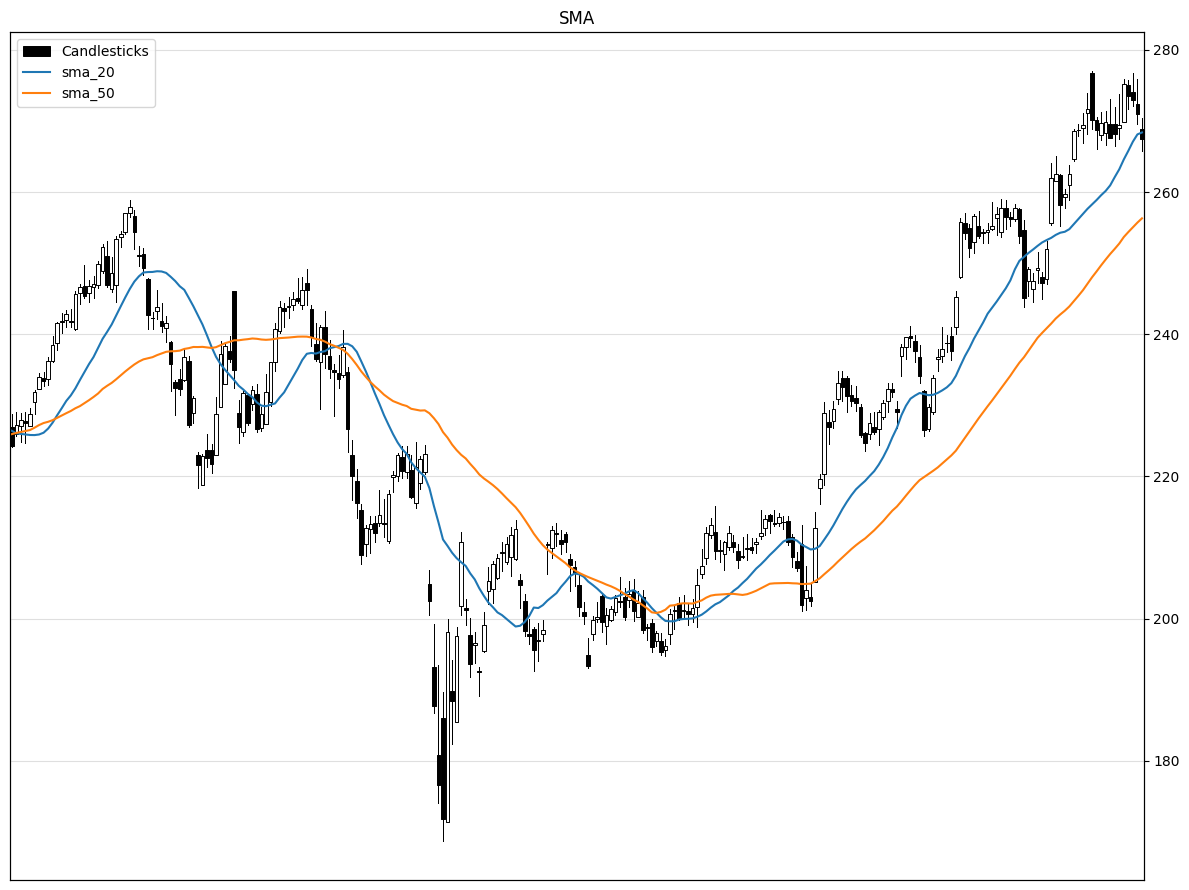

In [2]:
Chart(prices, title="SMA", max_bars=250).plot(
    Candlesticks(),
    SMA(20).alias("sma_20"),
    SMA(50).alias("sma_50"),
).show()

## RSI

Relative Strength Index with overbought / oversold lines.

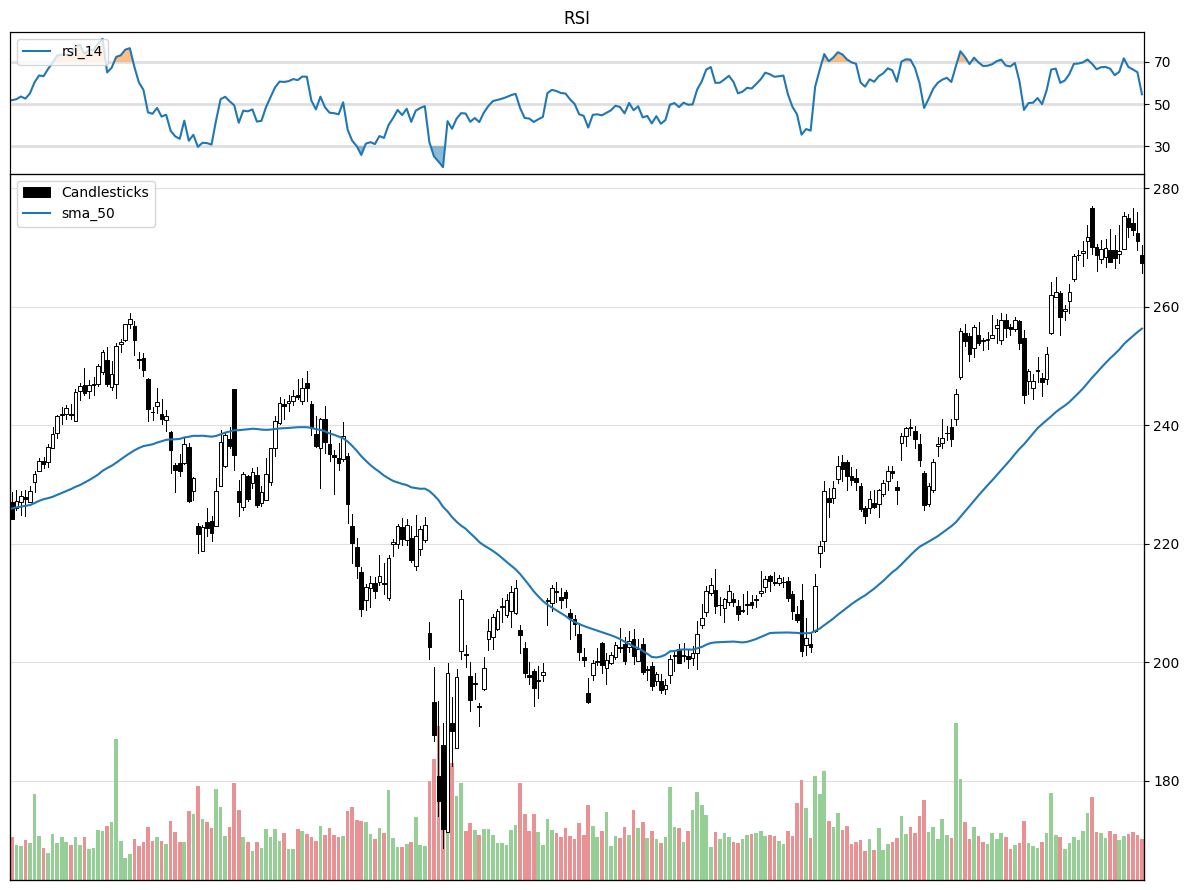

In [3]:
Chart(prices, title="RSI", max_bars=250).plot(
    Candlesticks(), SMA(50).alias("sma_50"), Volume(),
).pane("above", yticks=(30, 50, 70)).plot(
    RSI(14) @ LinePlot(label="rsi_14", overbought=70, oversold=30),
).show()

## MACD

Moving Average Convergence Divergence.

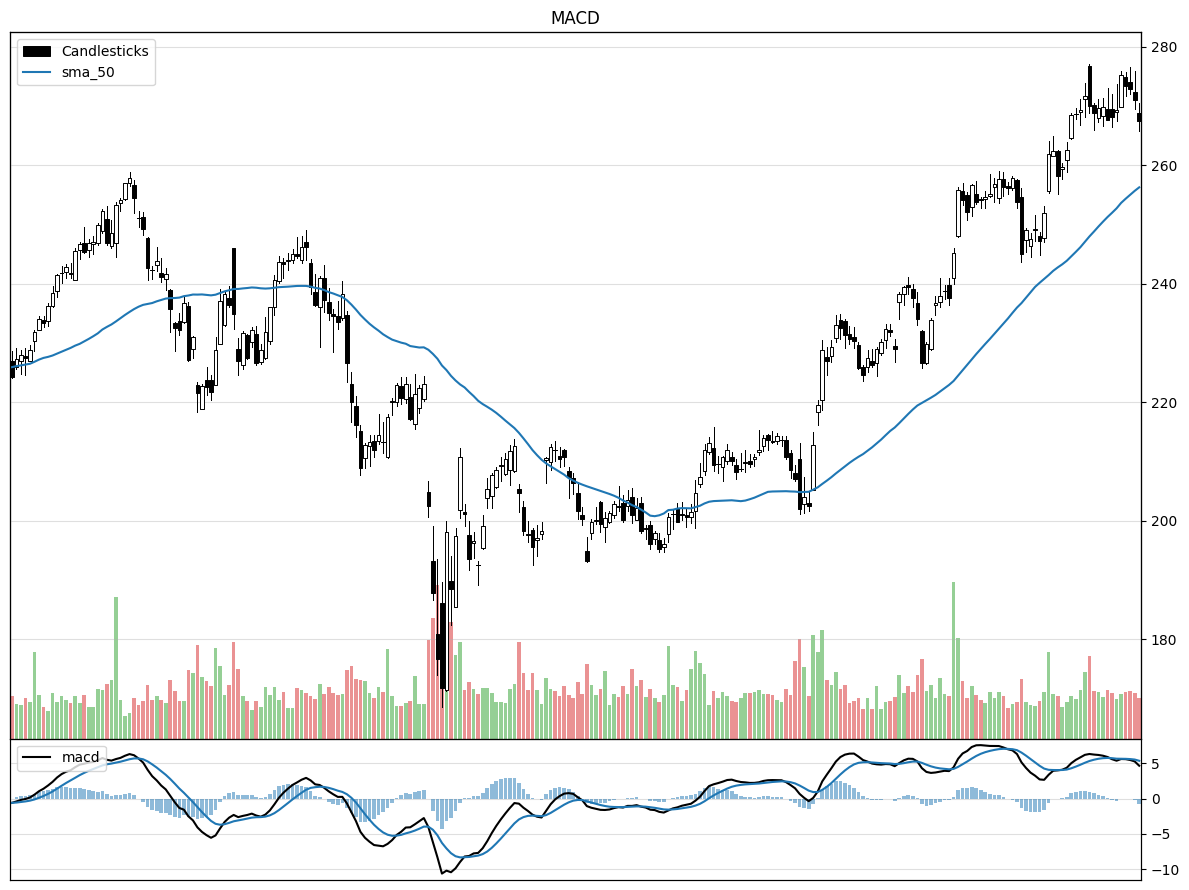

In [4]:
Chart(prices, title="MACD", max_bars=250).plot(
    Candlesticks(), SMA(50).alias("sma_50"), Volume(),
).pane("below").plot(
    MACD() @ AutoPlot(label="macd"),
).show()

## Bollinger Bands

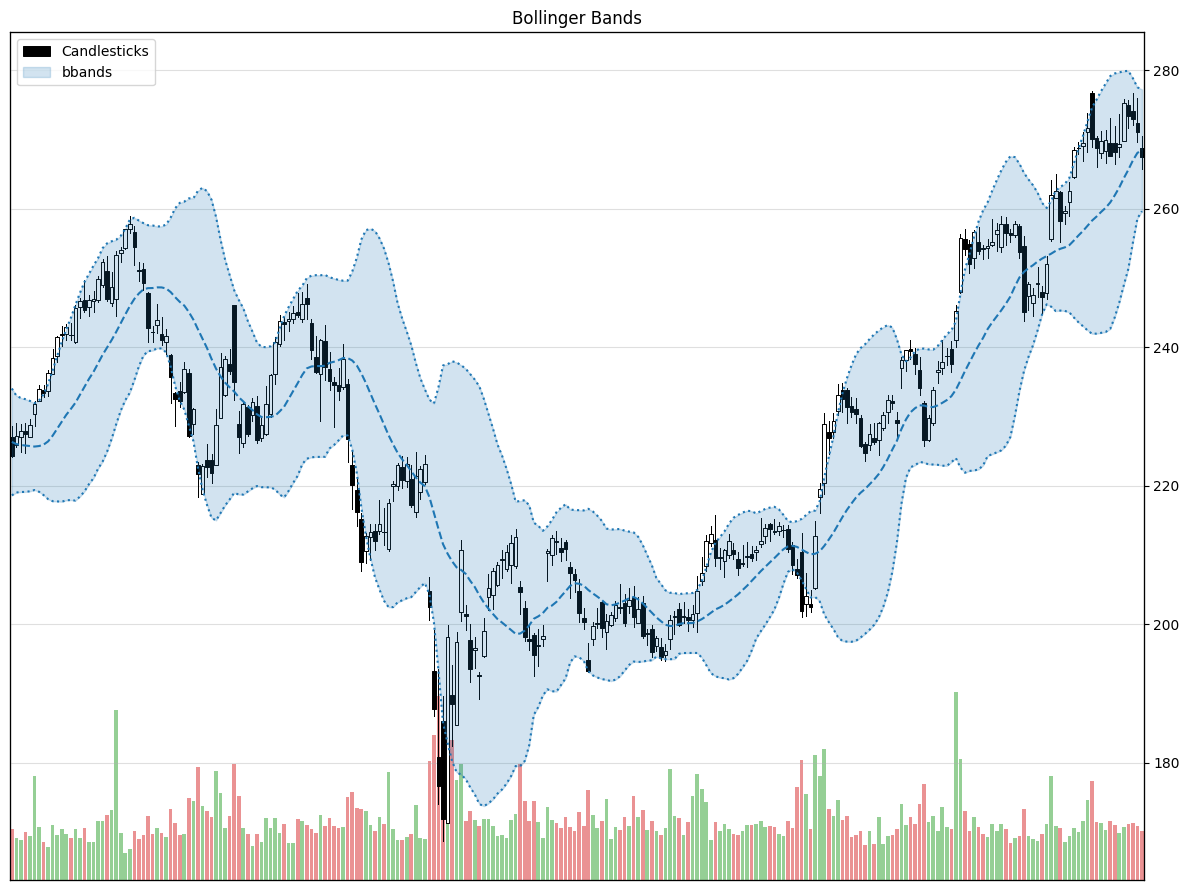

In [5]:
Chart(prices, title="Bollinger Bands", max_bars=250).plot(
    Candlesticks(), Volume(),
    BBANDS() @ AutoPlot(label="bbands"),
).show()

## DMI

Directional Movement Index: ADX with +DI and -DI.

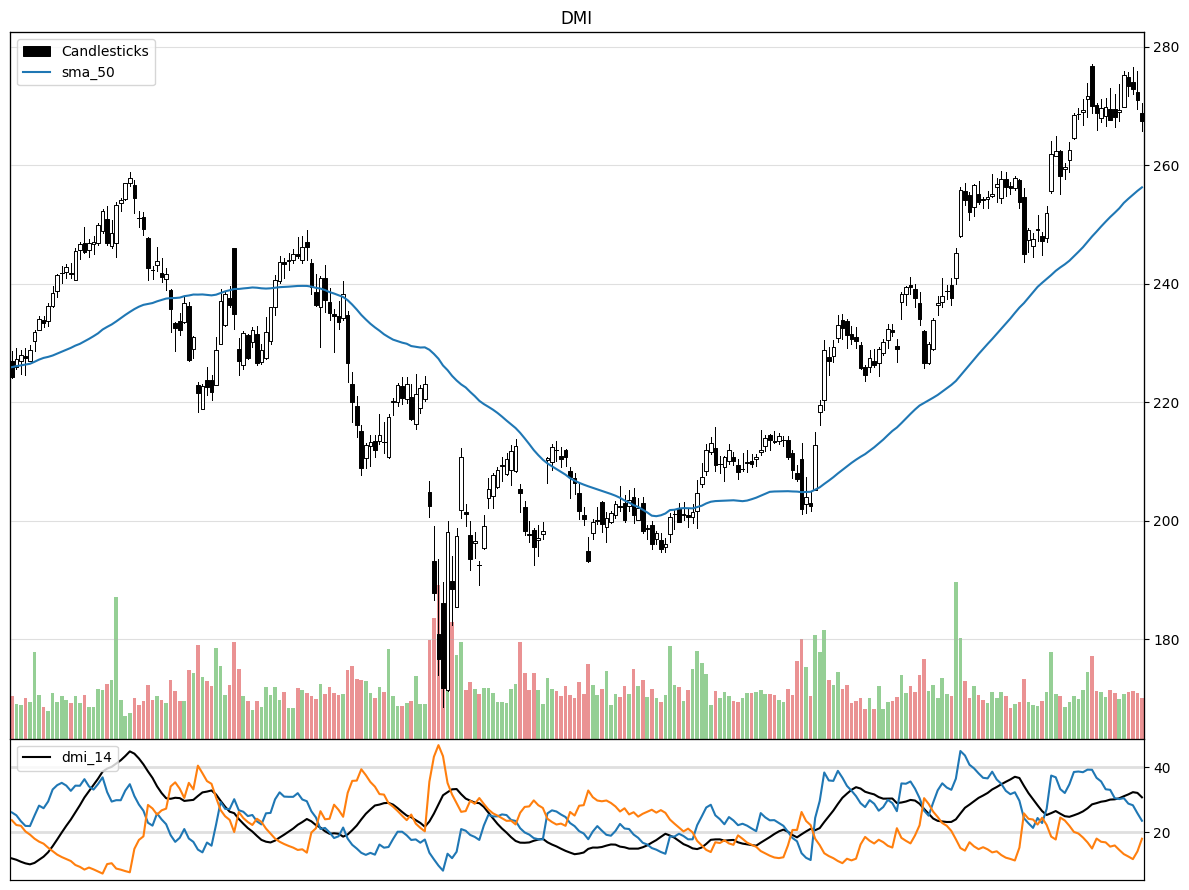

In [6]:
Chart(prices, title="DMI", max_bars=250).plot(
    Candlesticks(), SMA(50).alias("sma_50"), Volume(),
).pane("below", yticks=(20, 40)).plot(
    DMI(14) @ AutoPlot(label="dmi_14"),
).show()